In [1]:
%pip install openpyxl
%pip install scikit-learn
%pip install pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
from pandas import read_excel
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Boston = pd.read_excel('boston.xlsx')
Boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2310,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7070,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7070,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2180,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2180,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11930,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11930,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11930,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11930,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


<Axes: >

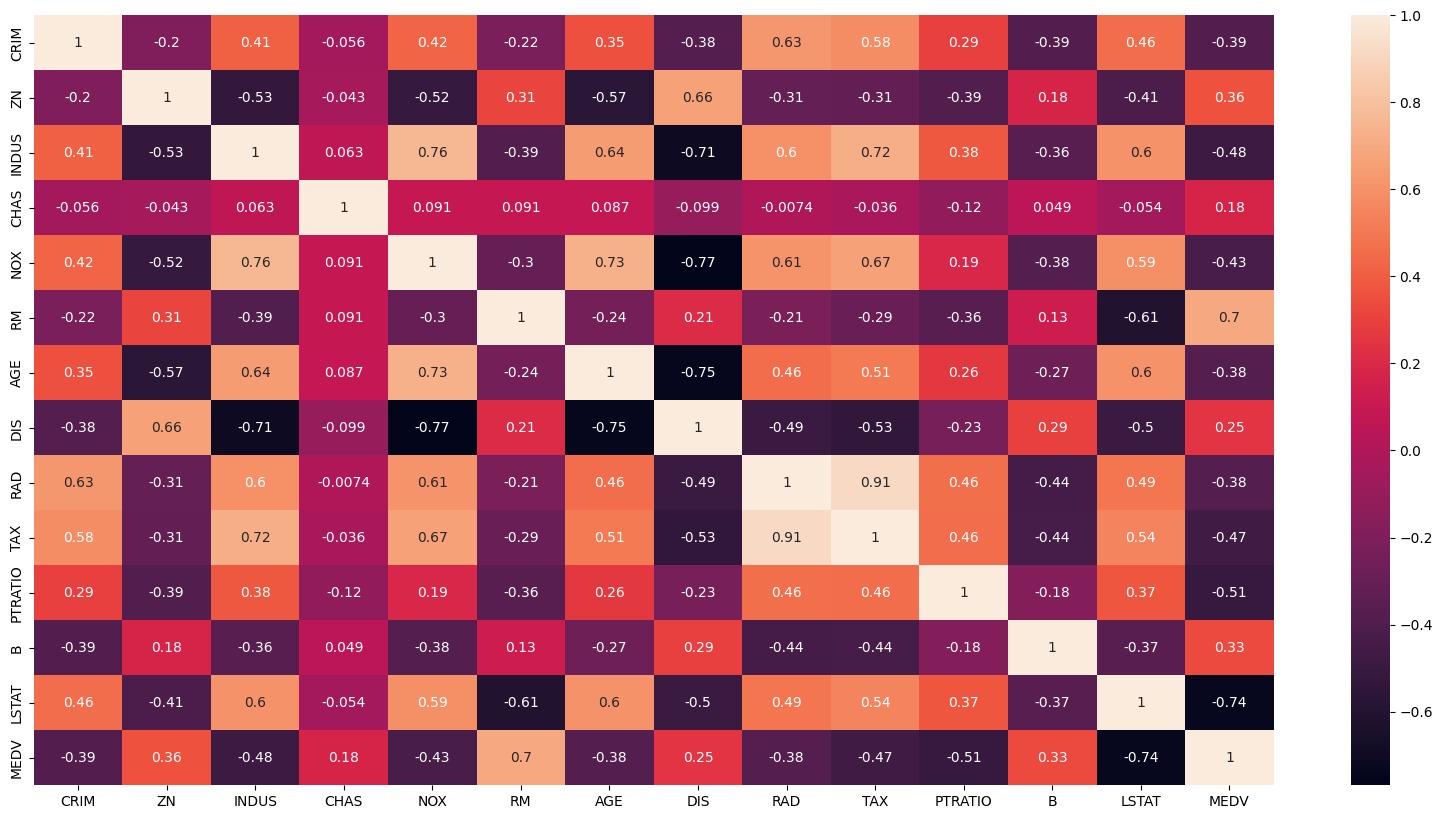

In [5]:
plt.figure(figsize=(20, 10))
sns.heatmap(Boston.corr(),  annot=True)

Predecir

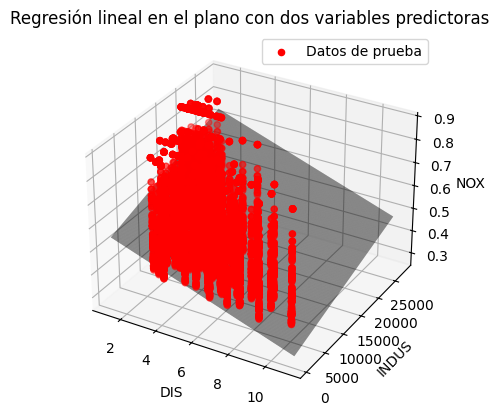

0.673614304639734
0.004575275851155831


In [6]:
#Division de los datos para 2 variables predictivas
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import axes3d
X = Boston[['DIS', 'INDUS']].values
y = Boston['NOX'].values.reshape(-1,1)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, train_size   = 0.8, random_state = 0, shuffle= True)
Y_train = Y_train.reshape(-1, 1)
model = LinearRegression()
model.fit(X_train, Y_train)

# definir el rango de valores para la variable predictiva "RM"
x1_range = np.arange(
    Boston['DIS'].min(),
    Boston['DIS'].max())

# definir el rango de valores para la variable predictiva "INDUS"
x2_range = np.arange(
    Boston['INDUS'].min(),
    Boston['INDUS'].max())

# crear una malla de puntos que cubra los rangos de valores de ambas variables predictoras
X1, X2 = np.meshgrid(x1_range, x2_range)

plano = pd.DataFrame(
    {
    'DIS':X1.ravel(),
    'INDUS':X2.ravel()
    })

# Hacer predicciones para cada punto de la malla
Z = model.predict(plano.values).reshape(X1.shape)

# Graficar
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Graficar puntos de datos
ax.scatter(X_test[:,0], X_test[:,1], Y_test, color='red', label='Datos de prueba')

# Graficar el plano de regresión
ax.plot_surface(X1, X2, Z, alpha=0.5, rstride=100, cstride=100, color='black')

# Etiquetas y leyenda
ax.set_xlabel('DIS')
ax.set_ylabel('INDUS')
ax.set_zlabel('NOX')
plt.title('Regresión lineal en el plano con dos variables predictoras')
plt.legend()

# Mostrar gráfico
plt.show()
# Hacer predicciones en los datos de prueba
y_pred = model.predict(X_test)

# Calcular el coeficiente de determinación (R^2)
print(r2_score(Y_test, y_pred))

# Calcular el error cuadrático medio (MSE)
print(mean_squared_error(Y_test, y_pred))


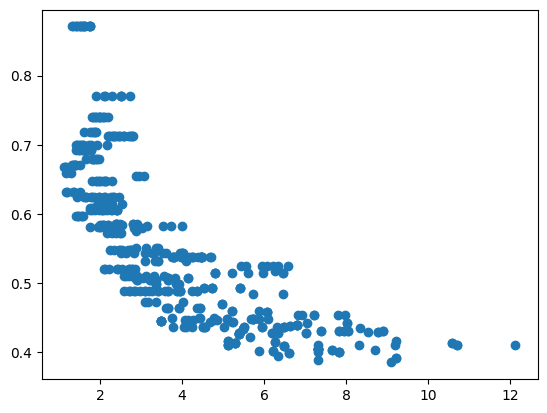

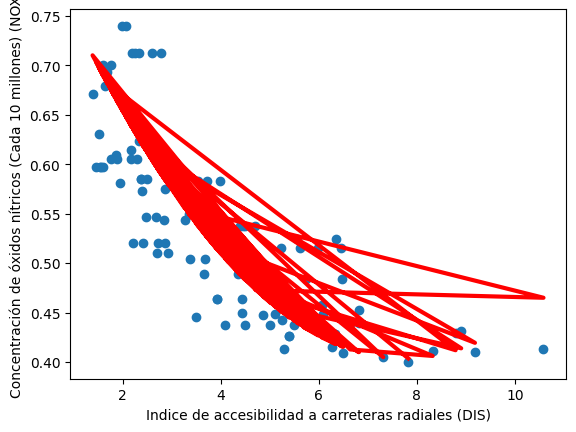

Precisión del modelo:
0.7046269147905576
0.0029976129443259674


In [7]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split

#Seleccionamos solamente la columna 'DIS' del dataset
X_p = Boston['DIS']
X_p = X_p.values.reshape(-1, 1)

#Defino los datos correspondientes a las etiquetas
y_p = Boston['NOX']

#Graficamos los datos correspondientes
plt.scatter(X_p, y_p)
plt.show()

#Separo los datos de "train" en entrenamiento y prueba para probar los algoritmos
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2)

#Se define el grado del polinomio
poli_reg = PolynomialFeatures(degree = 2)

#Se transforma las características existentes en características de mayor grado
X_train_poli = poli_reg.fit_transform(X_train_p)
X_test_poli = poli_reg.fit_transform(X_test_p)

#Defino el algoritmo a utilizar
pr = linear_model.LinearRegression()

#Entreno el modelo
pr.fit(X_train_poli, y_train_p)

#Realizo una predicción
Y_pred_pr = pr.predict(X_test_poli)

#Graficamos los datos junto con el modelo
plt.scatter(X_test_p, y_test_p)
plt.plot(X_test_p, Y_pred_pr, color='red', linewidth=3)
plt.xlabel("Indice de accesibilidad a carreteras radiales (DIS)")
plt.ylabel("Concentración de óxidos nítricos (Cada 10 millones) (NOX)")
plt.show()

print('Precisión del modelo:')
print(pr.score(X_train_poli, y_train_p))
print(mean_squared_error(y_test_p, Y_pred_pr))

## Conclusiones


1.   Al observar las métricas entre la regresion lineal multiple y la regresión polinomial se concluye que la regresion polinomial tiene una mayor precision respecto de la lineal multiple, pues su error es 0.001 menor al lineal y la correlación de las variables utilizadas es de 0.69 a partir de una aproximacion de grado 2, a medida que crece el grado del polinomio se acerca la correlación entre los datos hasta 0.71 frente al 0.77 que muestra la correlación de los datos del Dataset
2.   Al observar las gráficas proporcionadas tanto por el modelo lineal multiple y el modelo polinomico, se observa como el plano se ajusta bastante cerca a los puntos de test, mientras que la gráfica polinomica se ajusta a los puntos, parece mostrarse un comportamiento de sobreentrenamiento a medida que crece el grado del polinomio, por tanto se decide mantener el polinomio de grado 2 para no generar una interpolación en lugar de una regresión.

